# Tutorial 2 - Traffic Sign Classification with CNN and Adversarial Attacks

## 1. Dataset preparation

In [ ]:
! pip install torchcam

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torch.utils.data as data
from torchvision.models import vgg11_bn
from torchcam.methods import GradCAM
from torch.utils.data import random_split
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import os
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # set device
print(device)

cuda


In [ ]:
# Define transformations for the training and test sets
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load the training and test datasets without transformations
train_dataset = datasets.GTSRB(root='./data', split='train', transform=None, download=True)
test_dataset = datasets.GTSRB(root='./data', split='test', transform=None, download=True)

## 2. Splitting the dataset into training, validation and testing, and 3. resizing images if necessary

In [ ]:
# Function to check image size and resize if necessary
def conditional_resize(img, size=(32, 32), interpolation=Image.BICUBIC):
    if img.size != size:
        img = img.resize(size, interpolation)
    return img

# Apply the conditional resize and transformations to the datasets
train_dataset = [(conditional_resize(img, (32, 32)), label) for img, label in train_dataset]
test_dataset = [(conditional_resize(img, (32, 32)), label) for img, label in test_dataset]

# Apply the transformations to the resized datasets
train_dataset = [(transform(img), label) for img, label in train_dataset]
test_dataset = [(transform(img), label) for img, label in test_dataset]

# Split the training dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders for the training, validation, and test datasets
train_loader = data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Print the size of the datasets
print(f'Training dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(val_dataset)}')
print(f'Test dataset size: {len(test_dataset)}')

Training dataset size: 21312
Validation dataset size: 5328
Test dataset size: 12630


## 4. Designing the CNN model

### Convolution Layers in PyTorch

Convolution layers are a fundamental building block of Convolutional Neural Networks (CNNs). They apply a set of filters (kernels) to the input data to extract features such as edges, textures, and patterns. In PyTorch, convolution layers are implemented using the `torch.nn.Conv2d` class. These layers perform convolution operations followed by optional activation functions and pooling layers to reduce the spatial dimensions.

For more information on different types of convolution layers, their number of operations, and visualizations, you can refer to the following GitHub repository:

[Different Types of Convolution Layers - GitHub Repository](https://github.com/ZaGrayWolf/Types_of_Convolutions)

This repository provides a comprehensive overview of various convolution operations, including standard convolutions, transposed convolutions, and dilated convolutions, along with visualizations of their effects on input data.

In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNModel, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        # Dropout layer
        self.dropout = nn.Dropout(0.5)

        # Batch normalization layers
        self.batchnorm1 = nn.BatchNorm2d(32)
        self.batchnorm2 = nn.BatchNorm2d(64)
        self.batchnorm3 = nn.BatchNorm2d(128)
        self.batchnorm_fc1 = nn.BatchNorm1d(512)
        self.batchnorm_fc2 = nn.BatchNorm1d(256)

    def forward(self, x):
        # Convolutional layers with ReLU and batch normalization
        x = F.relu(self.batchnorm1(self.conv1(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.relu(self.batchnorm2(self.conv2(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = F.relu(self.batchnorm3(self.conv3(x)))
        x = F.max_pool2d(x, kernel_size=2, stride=2)

        # Flatten the tensor
        x = x.view(x.size(0), -1)

        # Fully connected layers with ReLU, batch normalization, and dropout
        x = F.relu(self.batchnorm_fc1(self.fc1(x)))
        x = self.dropout(x)

        x = F.relu(self.batchnorm_fc2(self.fc2(x)))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

# Example usage
model = CNNModel(num_classes=43)
print(model)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=43, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (batchnorm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm_fc1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batchnorm_fc2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


## 5. Defining loss function and optimizer, and training the model

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 1/20, Training Loss: 1.3565, Validation Loss: 0.2052
Epoch 2/20, Training Loss: 0.1858, Validation Loss: 0.0562
Epoch 3/20, Training Loss: 0.0863, Validation Loss: 0.0381
Epoch 4/20, Training Loss: 0.0532, Validation Loss: 0.0227
Epoch 5/20, Training Loss: 0.0440, Validation Loss: 0.0187
Epoch 6/20, Training Loss: 0.0418, Validation Loss: 0.0290
Epoch 7/20, Training Loss: 0.0242, Validation Loss: 0.0218
Epoch 8/20, Training Loss: 0.0239, Validation Loss: 0.0123
Epoch 9/20, Training Loss: 0.0290, Validation Loss: 0.0171
Epoch 10/20, Training Loss: 0.0312, Validation Loss: 0.0203
Epoch 11/20, Training Loss: 0.0187, Validation Loss: 0.0179
Epoch 12/20, Training Loss: 0.0201, Validation Loss: 0.0219
Epoch 13/20, Training Loss: 0.0205, Validation Loss: 0.0138
Epoch 14/20, Training Loss: 0.0150, Validation Loss: 0.0138
Epoch 15/20, Training Loss: 0.0148, Validation Loss: 0.0178
Epoch 16/20, Training Loss: 0.0105, Validation Loss: 0.0096
Epoch 17/20, Training Loss: 0.0130, Validation Lo

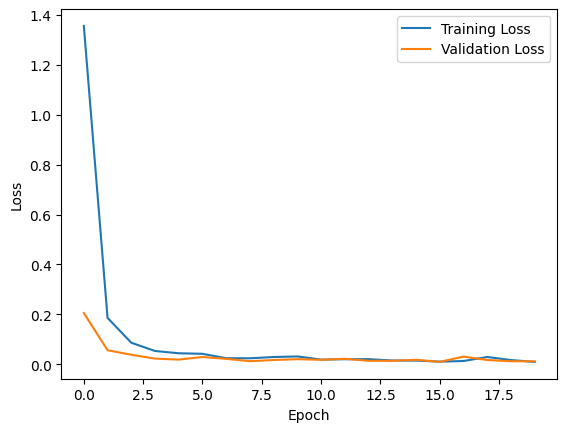

In [ ]:
num_epochs = 20
train_losses = []
val_losses = []
model=model.to(device)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}")

# Plot the training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 6. Evaluating the model

In [ ]:
# Function to evaluate the model on the test set
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, f1

# Evaluate the model
test_accuracy, test_f1 = evaluate_model(model, test_loader)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Test Accuracy: 0.9679
Test F1 Score: 0.9674


## 7. Adversarial attack (FGSM)
The Fast Gradient Sign Method (FGSM) is a simple yet effective adversarial attack technique introduced by Goodfellow et al. in 2014. It aims to generate adversarial examples by adding a small perturbation to the input image in the direction of the gradient of the loss function with respect to the input. The perturbation is controlled by a parameter epsilon (ε), which determines the magnitude of the perturbation. The goal is to create an adversarial example that is visually similar to the original image but causes the model to make incorrect predictions.

For more information on FGSM and its implementation in PyTorch, you can refer to the official PyTorch documentation:

1.[PyTorch FGSM Tutorial](https://pytorch.org/tutorials/beginner/fgsm_tutorial.html)
###
2.[Interactive Demo](https://jlin.xyz/advis/)

Additional Materials on Adversarial Attacks:
###
1.[ Explaining and Harnessing Adversarial Example](https://arxiv.org/abs/1412.6572)
###
2.[Different Types of Adversarial Attacks](https://arxiv.org/pdf/1804.00097)
###
3. [Adversarial Attacks on Speech Data](https://arxiv.org/pdf/1801.01944)
###


In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon * sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image

# restores the tensors to their original scale
def denorm(batch, mean=[0.5], std=[0.5]):
    """
    Convert a batch of tensors to their original scale.

    Args:
        batch (torch.Tensor): Batch of normalized tensors.
        mean (torch.Tensor or list): Mean used for normalization.
        std (torch.Tensor or list): Standard deviation used for normalization.

    Returns:
        torch.Tensor: batch of tensors without normalization applied to them.
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

## 8. Visualization of perturbations

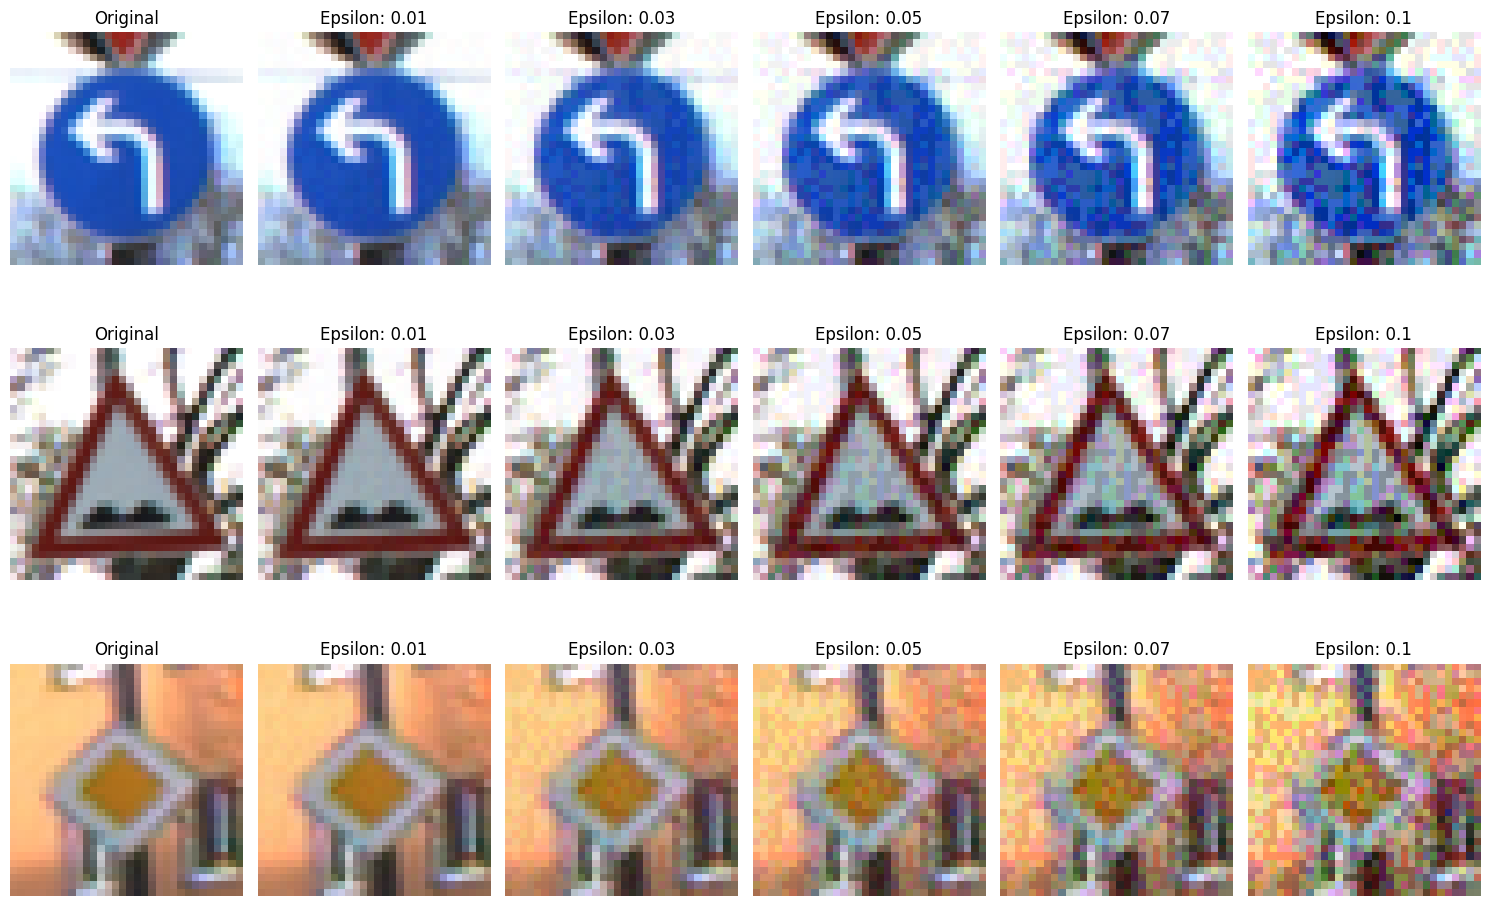

In [ ]:
# Function to generate adversarial samples
def generate_adversarial_samples(model, data, target, epsilon):
    #data should be normalized, i.e, output of  the data of the dataloader
    data.requires_grad = True
    target=target.to(device)
    data=data.to(device)
    output = model(data)
    loss = F.cross_entropy(output, target)
    model.zero_grad()
    loss.backward()
    data_grad = data.grad.data
    data_denorm = denorm(data)
    perturbed_data = fgsm_attack(data_denorm, epsilon, data_grad)
    perturbed_data = transforms.Normalize((0.5,), (0.5,))(perturbed_data)
    #output is also normalized adversarial data
    return perturbed_data

# Randomly pick 3 classes from the test set
random_classes = random.sample(range(43), 3)
epsilon_values = [0.01, 0.03, 0.05, 0.07, 0.1]

# Generate and visualize adversarial samples
fig, axes = plt.subplots(len(random_classes), len(epsilon_values) + 1, figsize=(15, 10))

for i, cls in enumerate(random_classes):
    for data, target in test_loader:
        if (target.item() == cls) and (data.mean() > 0.1) and (data.mean() < 25.0):
            # Plot original image
            data=data.to(device)
            data_denorm = denorm(data)  # Restore the data to its original scale for plotting
            axes[i, 0].imshow(np.transpose(data_denorm.squeeze().cpu().numpy(), (1, 2, 0)))
            axes[i, 0].set_title("Original")
            axes[i, 0].axis('off')

            # Plot adversarial samples for different epsilon values
            for j, epsilon in enumerate(epsilon_values):
                adv_data = generate_adversarial_samples(model, data, target, epsilon) #input and output are normalized
                data_denorm = denorm(adv_data)  # Restore the data to its original scale
                axes[i, j + 1].imshow(np.transpose(data_denorm.squeeze().detach().cpu().numpy(), (1, 2, 0)))
                axes[i, j + 1].set_title(f"Epsilon: {epsilon}")
                axes[i, j + 1].axis('off')
            break

plt.tight_layout()
plt.show()

## 9. Model performance on perturbed images

In [ ]:
def evaluate_adversarial_samples(model, test_loader, epsilon):
    model.eval()
    all_preds = []
    all_labels = []
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        adv_data = generate_adversarial_samples(model, data, target, epsilon)
        output = model(adv_data)
        _, preds = torch.max(output, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(target.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return accuracy, f1

# Set the epsilon value for FGSM (largest value for visually indistinguishable images)
epsilon = 0.01

# Evaluate the model on adversarial samples
adv_accuracy, adv_f1 = evaluate_adversarial_samples(model, test_loader, epsilon)
print(f"Adversarial Test Accuracy: {adv_accuracy:.4f}")
print(f"Adversarial Test F1 Score: {adv_f1:.4f}")

Adversarial Test Accuracy: 0.5713
Adversarial Test F1 Score: 0.5836


## 10. Examples of misclassification

In [ ]:
# Function to evaluate the model on adversarial samples and show misclassifications
def evaluate_and_show_misclassifications(model, test_loader, epsilon):
    model.eval()
    model=model.to(device)
    misclassified_examples = []

    for data, target in test_loader:
        data, target = data.to(device), target.to(device)

        # Original prediction
        output = model(data)
        _, orig_pred = torch.max(output, 1)

        # Generate adversarial sample
        adv_data = generate_adversarial_samples(model, data, target, epsilon)

        # Adversarial prediction
        output = model(adv_data)
        _, adv_pred = torch.max(output, 1)

        data_denorm=denorm(data)
        adv_data_denorm=denorm(adv_data)
        # Check for misclassification
        if orig_pred.item() == target.item() and adv_pred.item() != target.item():
            misclassified_examples.append((data_denorm.squeeze().cpu(), adv_data_denorm.squeeze().cpu(), target.item(), adv_pred.item()))

    return misclassified_examples

# Set the epsilon value for FGSM (largest value for visually indistinguishable images)
epsilon = 0.01

# Evaluate the model and get misclassified examples
misclassified_examples = evaluate_and_show_misclassifications(model, test_loader, epsilon)


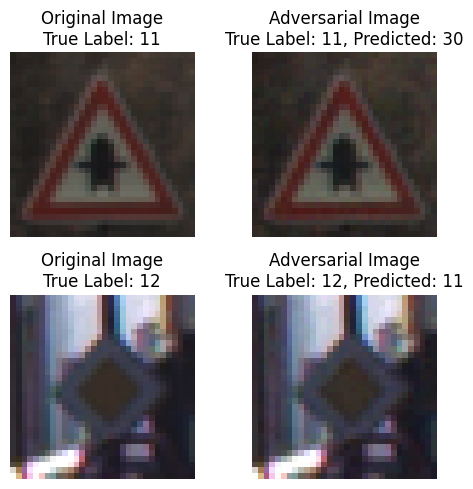

In [ ]:
# Show some misclassified examples
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

for i, (orig_img, adv_img, true_label, adv_label) in enumerate(misclassified_examples):

    if i==2: break
    axes[i, 0].imshow(np.transpose(orig_img.detach().cpu().numpy(), (1, 2, 0)))
    axes[i, 0].set_title(f"Original Image\nTrue Label: {true_label}")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(np.transpose(adv_img.detach().cpu().numpy(), (1, 2, 0)))
    axes[i, 1].set_title(f"Adversarial Image\nTrue Label: {true_label}, Predicted: {adv_label}")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## 11. Finetuning (pre-trained VGG network)

Epoch 1/20, Training Loss: 2.3493, Validation Loss: 1.1725
Epoch 2/20, Training Loss: 1.0343, Validation Loss: 0.5710
Epoch 3/20, Training Loss: 0.5875, Validation Loss: 0.3260
Epoch 4/20, Training Loss: 0.3701, Validation Loss: 0.2049
Epoch 5/20, Training Loss: 0.2551, Validation Loss: 0.1443
Epoch 6/20, Training Loss: 0.1875, Validation Loss: 0.1078
Epoch 7/20, Training Loss: 0.1363, Validation Loss: 0.0882
Epoch 8/20, Training Loss: 0.1061, Validation Loss: 0.0701
Epoch 9/20, Training Loss: 0.0835, Validation Loss: 0.0607
Epoch 10/20, Training Loss: 0.0686, Validation Loss: 0.0533
Epoch 11/20, Training Loss: 0.0545, Validation Loss: 0.0449
Epoch 12/20, Training Loss: 0.0448, Validation Loss: 0.0415
Epoch 13/20, Training Loss: 0.0377, Validation Loss: 0.0383
Epoch 14/20, Training Loss: 0.0310, Validation Loss: 0.0349
Epoch 15/20, Training Loss: 0.0265, Validation Loss: 0.0330
Epoch 16/20, Training Loss: 0.0232, Validation Loss: 0.0335
Epoch 17/20, Training Loss: 0.0207, Validation Lo

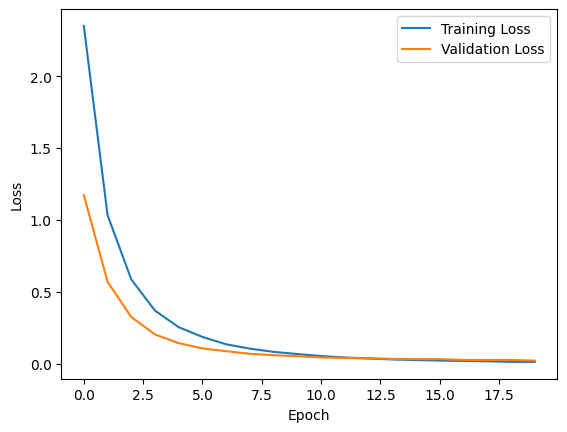

In [ ]:
import torch.utils.data as data

# Define the transformations for the dataset
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load the training and test datasets without transformations
train_dataset = datasets.GTSRB(root='./data', split='train', transform=transform, download=True)
test_dataset = datasets.GTSRB(root='./data', split='test', transform=transform, download=True)

# Split the training dataset into training and validation sets
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create data loaders for the training, validation, and test datasets
train_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = data.DataLoader(test_dataset, batch_size=1, shuffle=False)

# Load the pretrained VGG-11 model with batch normalization
model = vgg11_bn(weights=torchvision.models.VGG11_BN_Weights.IMAGENET1K_V1)

# Freeze the convolutional layers
for param in model.features.parameters():
    param.requires_grad = False

# Replace the classifier part of the model
num_classes = 43
model.avgpool = nn.AdaptiveAvgPool2d((4, 4))
model.classifier = nn.Sequential(
    nn.Linear(512 * 4 * 4, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, num_classes),
)

# Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

# Training loop
num_epochs = 20
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_losses.append(running_loss / len(train_loader))

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_losses.append(val_loss / len(val_loader))

    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f}")

# Plot the training and validation losses
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 12. Fine-tuned model performance

In [ ]:
# Evaluate the model on the test set
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.8878
Test F1 Score: 0.8856


## 13. Visualizing Class Activation Maps (CAMs)
CAM, short for Class Acvtivation Mapping, is a technique that visualizes the regions of input that are "important" for predictions from these models - or visual explanations. Relying on localization properties of a final global average pooling layer in the network, CAM uses the class-specific gradient information flowing into the final convolutional layer of a CNN to produce a coarse localization map of the discriminative regions in the image.
Reference: [Learning Deep Features for Discriminative Localization. (Zhou et al.)](http://cnnlocalization.csail.mit.edu/)

### Tools
1. [CAM-Visualizer: Class Activation Map Visualization Toolkit](https://www.intel.com/content/www/us/en/developer/articles/reference-implementation/class-activation-map-visualizer.html)

### Interactive Demos
1. [CNN Explainer](https://poloclub.github.io/cnn-explainer/)
###
2. [Summit](https://fredhohman.com/summit/)

### Additional Materials
1. [Overview of Class Activation Maps for Visualization Explainability](https://arxiv.org/pdf/2309.14304)
###
2. [Various CAM visualizatoin methods with tutorials](https://www.pinecone.io/learn/class-activation-maps/)
###
3. [Activation Atlas](https://distill.pub/2019/activation-atlas/)

In [ ]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

# Initialize GradCAM with the model and the target layer
cam_extractor = GradCAM(model, target_layer='features.27')
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

In [ ]:
# Function to visualize CAMs
def visualize_cam(model, cam_extractor, data_loader, device):
    count=0
    model.eval()
    for i, (inputs, labels) in enumerate(data_loader):
      if inputs.mean() > 0.1:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        inputs.requires_grad = True
        outputs = model(inputs)
        max_prob, preds = torch.max(outputs, 1)

        # Generate CAM
        count+=1
        activation_map = cam_extractor(preds.item(), outputs)

        # Convert tensor to PIL image
        inputs=inputs * torch.tensor(std).view(3, 1, 1).to(device)
        inputs=inputs + torch.tensor(mean).view(3, 1, 1).to(device)
        img = transforms.ToPILImage(mode='RGB')(inputs[0].squeeze().cpu())

        # Convert activation map to PIL image
        mask = activation_map[0].squeeze().cpu().numpy()
        mask = Image.fromarray(mask, mode='F')
        # Overlay the CAM on the image
        result = overlay_mask(img, mask, alpha=0.5)
        # Display the image and CAM
        plt.figure(figsize=(7, 3))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image\nTrue Label: {labels.item()}")
        plt.axis('off')

        # print(np.asarray(img).shape)
        plt.subplot(1, 2, 2)
        plt.imshow(np.asarray(result))
        plt.title(f"CAM\nPredicted: {preds.item()}")
        plt.axis('off')

        plt.show()

        if count == 15:  # Show only a few examples
            break


In [ ]:
# Visualize CAMs for a few test samples
visualize_cam(model, cam_extractor, test_loader, device)

Output hidden; open in https://colab.research.google.com to view.